🎯 FINAL PPG ANALYSIS

📅 Analysis Range (200Hz measurement time):
   Start: 2025-09-11 22:47:00
   End: 2025-09-12 07:08:00
   Duration: 8.3 hours

📂 Loading 25Hz: E0001.csv
   Shape: (153000, 10)
   🔧 Trying today + time reconstruction...
   Today values: ['2025-09-11' '2025-09-12']
   ✅ Method: today + time (Adaptive + UNWRAP + DEQUANTIZE)
   📅 Reconstructed range: 2025-09-11 22:54:01.052000 ~ 2025-09-12 07:00:04.054000
   Duration: 8.10 hours
   📅 Final range: 2025-09-11 22:54:01.052000 ~ 2025-09-12 07:00:04.054000
   🎯 Matched: 153,000 / 153,000 (100.0%)

📂 Loading 200Hz: ppgRaw.csv
   📅 Range: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:47.152346
   Samples: 6,066,288

📊 Samples in analysis range:
   25Hz: 153,000
   200Hz: 6,056,774

🔍 Found 17 measurement periods
   Scheduled periods: 17
   Period 0: 22:54:01 ~ 23:00:03 → 1 bursts
   Period 1: 23:24:01 ~ 23:30:03 → 1 bursts
   Period 2: 23:54:01 ~ 00:00:03 → 1 bursts
   Total: 17 periods with bursts

📊 Analyzing windows...
💾 Saved 187

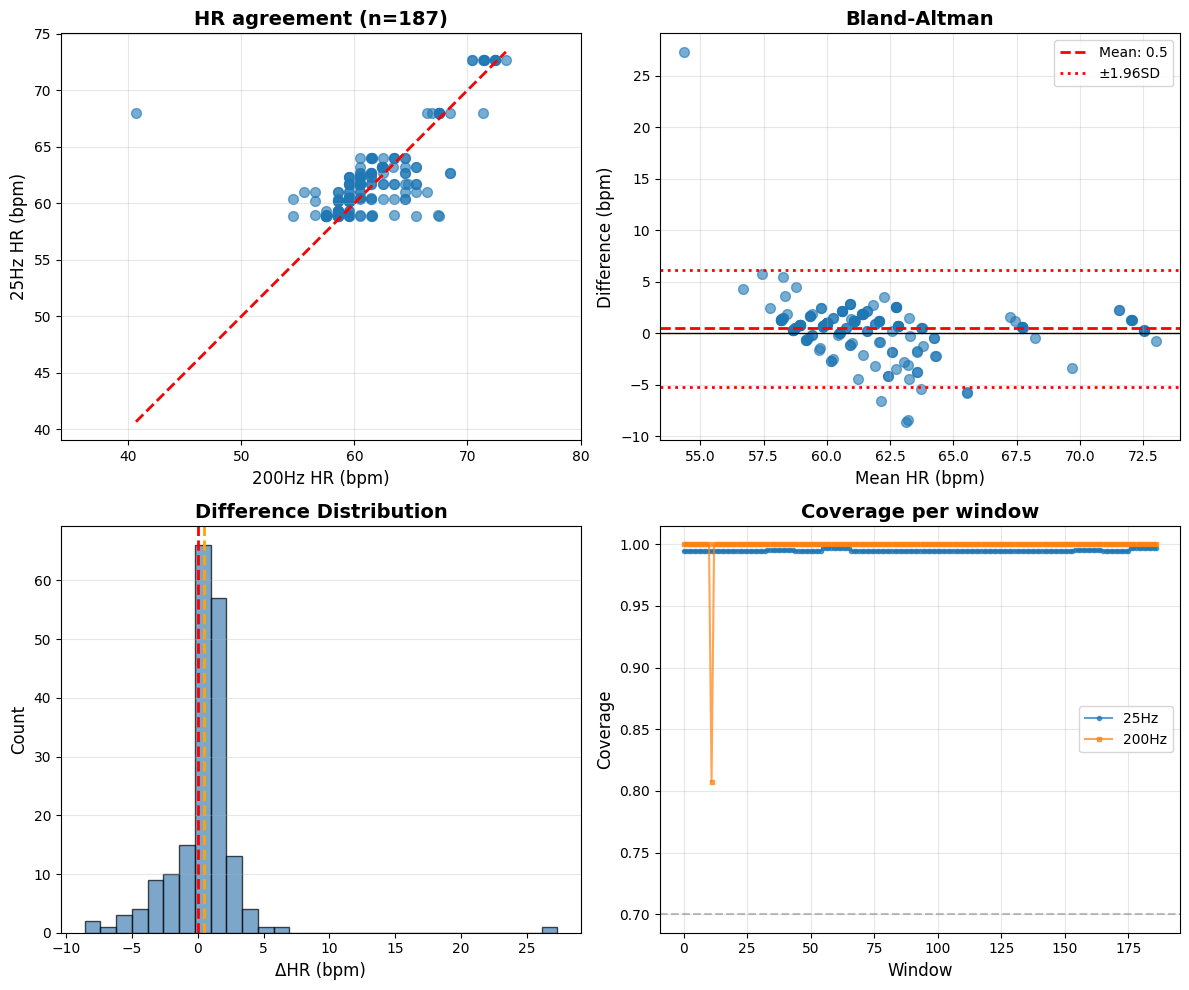


✅ Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/final_analysis_analysis.png

✅ Complete!


In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL: 200Hz time = analysis range, 25Hz auto-find matching
# ============================================================

CFG = {
    # ============================================================
    # FILES
    # ============================================================
    "FILE_25": "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv",
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv",

    # ============================================================
    # ANALYSIS RANGE (200Hz 측정 시간 기준)
    # ============================================================
    "NIGHT_START": "2025-09-11 22:47:00",
    "NIGHT_END": "2025-09-12 07:08:00",

    # ============================================================
    # SETTINGS
    # ============================================================
    "PPG_COL_25": "ppg",

    "READ200_HEADER_NONE": True,
    "T_COL_200": 0,
    "PPG_COL_200": 1,
    "T_UNIT_200": "us",

    "FS_25": 25,
    "FS_200": 200,

    # SCHEDULE
    "SCHED": [
        {"start_min": 20, "end_min": 30},
        {"start_min": 50, "end_min": 60},
    ],

    # ANALYSIS PARAMS
    "MAX_GAP_LONG_SEC": 60,
    "MIN_SEGMENT_SEC": 60,
    "BURST_GAP_SEC": 15,
    "MIN_BURST_SEC": 8,
    "WIN_SEC": 60,
    "STEP_SEC": 30,

    # QC
    "MIN_VALID_RATIO_25": 0.70,
    "MIN_COV_EXPECT_200": 0.90,
    "MIN_SNR_DB": -10.0,

    # OUTPUT
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_sched_full",
    "RUN_ID": "final_analysis",
}

os.makedirs(CFG["OUT_DIR"], exist_ok=True)

# ============================================================
# Smart 25Hz Loader - Auto-find matching time range
# ============================================================
# ============================================================
# Smart 25Hz Loader - Auto-find matching time range
#  - E0001 (1).csv : datetime/timestamp가 샘플별(ms)로 존재 → 그대로 사용
#  - E0001_2.csv   : time이 0.1s 양자화(MM:SS.t)로 중복 다수 → 25Hz로 de-quantize
# ============================================================
def load_25hz_auto_match(filepath, ppg_col, target_start, target_end, allow_forced_shift=False,
                         expected_fs=25.0, dequantize_unique_ratio_thr=0.85):
    """
    Robust loader
    - today + time: HH:MM:SS(.sss) / MM:SS(.sss or .t) 모두 파싱
    - MM:SS가 매시간 00으로 리셋되는 경우 자동 unwrap(+3600s 누적)
    - time이 0.1s 분해능 등으로 양자화되어 dt 중복이 많으면(예: coverage~0.4),
      같은 time-bin 내부 샘플을 25Hz(0.04s)로 미세 분배(de-quantize)하여 dt 복원
    - datetime 컬럼은 '날짜가 포함된 문자열'일 때만 사용(예: 2025-..)
    - timestamp는 샘플별 유니크가 충분할 때만 epoch로 사용(블록 단위 timestamp 방지)
    - Forced shift는 기본 OFF (allow_forced_shift=True일 때만)
    """
    import os
    import numpy as np
    import pandas as pd
    import re

    df = pd.read_csv(filepath)

    print(f"📂 Loading 25Hz: {os.path.basename(filepath)}")
    print(f"   Shape: {df.shape}")

    dt = None

    # ------------------------------------------------------------
    # helper: time-bin 양자화(중복 dt)일 때 25Hz로 미세 분배
    # ------------------------------------------------------------

    def _maybe_dequantize_datetime(dt_series: pd.Series, fs: float) -> pd.Series:
      dt_series = pd.Series(dt_series).reset_index(drop=True)
      ok = dt_series.notna().to_numpy()
      if ok.mean() < 0.5:
          return dt_series

      uniq_ratio = dt_series[ok].nunique() / ok.sum()

      t = dt_series[ok].values.astype("datetime64[ns]")
      if len(t) < 3:
          return dt_series

      d_ns = np.diff(t).astype("timedelta64[ns]").astype(np.int64)
      d_pos = d_ns[d_ns > 0]
      if len(d_pos) == 0:
          return dt_series

      med_step = np.median(d_pos) / 1e9  # seconds
      quantized = (uniq_ratio < dequantize_unique_ratio_thr) or (med_step >= 0.08)
      if not quantized:
          return dt_series

      print(f"   ⚠️ Detected quantized/duplicated dt: unique_ratio={uniq_ratio:.3f}, med_step={med_step:.3f}s")
      print(f"   🔧 De-quantizing within duplicated time-bins to ~{fs:.1f}Hz...")

      dt_out = dt_series.copy()
      base = dt_series.values.astype("datetime64[ns]")

      i = 0
      n = len(dt_series)
      step_ns_default = int(round(1e9 / fs))

      while i < n:
          if pd.isna(dt_series.iloc[i]):
              i += 1
              continue

          j = i + 1
          while j < n and (base[j] == base[i]):
              j += 1

          g_len = j - i
          if g_len > 1:
              if j < n and not pd.isna(dt_series.iloc[j]):
                  next_base = base[j]
                  step_ns = int((next_base - base[i]).astype("timedelta64[ns]").astype(np.int64))
                  if step_ns <= 0:
                      step_ns = step_ns_default * g_len
              else:
                  step_ns = step_ns_default * g_len

              desired_last = step_ns_default * (g_len - 1)
              if desired_last < step_ns:
                  offs = np.arange(g_len, dtype=np.int64) * step_ns_default
              else:
                  max_span = max(step_ns - 1, 0)
                  offs = np.linspace(0, max_span, g_len).round().astype(np.int64)

              for k in range(g_len):
                  dt_out.iloc[i + k] = pd.Timestamp(base[i]) + pd.to_timedelta(int(offs[k]), unit="ns")

          i = j

      # 단조성 보정(cummax 성격)
      dt_ns = pd.Series(dt_out).values.astype("datetime64[ns]").astype(np.int64)
      mask = pd.Series(dt_out).notna().to_numpy()
      dt_ns_fix = dt_ns.copy()
      for idx in range(1, n):
          if mask[idx] and mask[idx - 1] and dt_ns_fix[idx] < dt_ns_fix[idx - 1]:
              dt_ns_fix[idx] = dt_ns_fix[idx - 1]

      # ✅ 여기서 DatetimeIndex/ndarray로 떨어질 수 있으니, 무조건 Series로 고정
      dt_out = pd.to_datetime(dt_ns_fix, unit="ns", errors="coerce")
      dt_out = pd.Series(dt_out).reset_index(drop=True)

      ok2 = dt_out.notna().to_numpy()
      uniq_ratio2 = (dt_out[ok2].nunique() / ok2.sum()) if ok2.sum() > 0 else np.nan
      print(f"   ✅ De-quantized unique_ratio: {uniq_ratio2:.3f} (was {uniq_ratio:.3f})")

      return dt_out



    # ============================================================
    # TRY 0: today + time reconstruction (Robust Parse + UNWRAP + DEQUANTIZE)
    # ============================================================
    if 'today' in df.columns and 'time' in df.columns:
        print(f"   🔧 Trying today + time reconstruction...")

        today_values = df['today'].dropna().unique()
        print(f"   Today values: {today_values}")

        base_dates = pd.to_datetime(df['today'], errors='coerce')

        # time string 전처리
        tstr = df['time'].astype(str).str.strip()
        colon_cnt = tstr.str.count(':')

        tsec = np.full(len(df), np.nan, dtype=float)

        # --- HH:MM:SS(.sss)
        mask3 = (colon_cnt == 2)
        if mask3.any():
            parts3 = tstr[mask3].str.split(':', n=2, expand=True)
            h = pd.to_numeric(parts3[0], errors='coerce')
            m = pd.to_numeric(parts3[1], errors='coerce')
            s = pd.to_numeric(parts3[2], errors='coerce')
            tsec3 = (h * 3600.0 + m * 60.0 + s).to_numpy(dtype=float)
            tsec[np.where(mask3)[0]] = tsec3

        # --- MM:SS(.sss or .t)
        mask2 = (colon_cnt == 1)
        if mask2.any():
            parts2 = tstr[mask2].str.split(':', n=1, expand=True)
            m = pd.to_numeric(parts2[0], errors='coerce')
            s = pd.to_numeric(parts2[1], errors='coerce')
            tsec2 = (m * 60.0 + s).to_numpy(dtype=float)
            idx2 = np.where(mask2)[0]
            tsec[idx2] = tsec2

        valid_ratio = np.isfinite(tsec).mean()

        if valid_ratio > 0.5 and base_dates.notna().mean() > 0.5:
            # ✅ MM:SS 리셋 unwrap (day별로 수행)
            tsec_unwrap = tsec.copy()
            days = base_dates.dt.floor('D')

            for day in days.dropna().unique():
                idx = np.where((days == day).to_numpy())[0]
                if len(idx) < 2:
                    continue

                ts = tsec_unwrap[idx]
                valid = np.isfinite(ts)
                if valid.sum() < 2:
                    continue

                # NaN 때문에 diff 깨지는 것 방지: 간단 전방채움
                ts_work = ts.copy()
                for ii in range(1, len(ts_work)):
                    if (not np.isfinite(ts_work[ii])) and np.isfinite(ts_work[ii-1]):
                        ts_work[ii] = ts_work[ii-1]

                d = np.diff(ts_work)
                wraps = np.zeros(len(ts_work), dtype=int)
                wraps[1:] = (d < -5.0).astype(int)  # 5초 이상 뒤로 점프하면 reset로 간주
                ts_unw = ts + 3600.0 * np.cumsum(wraps)

                tsec_unwrap[idx] = ts_unw

            dt_test = base_dates + pd.to_timedelta(tsec_unwrap, unit='s')
            dt_test = pd.Series(dt_test)

            if dt_test.notna().mean() > 0.5:
                # ★ 추가: time 양자화/중복 dt 자동 보정 (E0001_2 대응)
                dt_test = _maybe_dequantize_datetime(dt_test, fs=expected_fs)

                dt = dt_test
                print(f"   ✅ Method: today + time (Adaptive + UNWRAP + DEQUANTIZE)")
                print(f"   📅 Reconstructed range: {dt.min()} ~ {dt.max()}")
                duration_hours = (dt.max() - dt.min()).total_seconds() / 3600
                print(f"   Duration: {duration_hours:.2f} hours")

    # ============================================================
    # TRY 1: 'datetime' column with full timestamp (날짜 포함일 때만)
    # ============================================================
    if dt is None and 'datetime' in df.columns:
        s = df['datetime'].astype(str)
        # 날짜 패턴이 충분히 있어야만 사용
        has_date = s.str.contains(r'\d{4}[-/]\d{2}[-/]\d{2}', regex=True)
        if has_date.mean() > 0.5:
            dt_test = pd.to_datetime(df['datetime'], errors='coerce')
            valid_ratio = dt_test.notna().mean()
            if valid_ratio > 0.5:
                valid_dates = dt_test.dropna()
                if len(valid_dates) > 0 and 2000 <= valid_dates.iloc[0].year <= 2030:
                    dt = pd.Series(dt_test).reset_index(drop=True)
                    print(f"   ✅ Method: 'datetime' column (full date detected)")

    # ============================================================
    # TRY 2: 'timestamp' (ms or sec) - 샘플별 유니크할 때만
    # ============================================================
    if dt is None and 'timestamp' in df.columns:
        t_val = pd.to_numeric(df['timestamp'], errors='coerce')
        if t_val.notna().mean() > 0.9:
            nunique_ratio = t_val.nunique(dropna=True) / len(t_val)
            # 블록 단위 timestamp(유니크 매우 적음) 배제
            if nunique_ratio > 0.8:
                dt_ms = pd.to_datetime(t_val, unit='ms', errors='coerce')
                if dt_ms.notna().any() and 2020 <= dt_ms.dt.year.dropna().mean() <= 2030:
                    dt = pd.Series(dt_ms).reset_index(drop=True)
                    print(f"   ✅ Method: 'timestamp' (epoch ms)")
                else:
                    dt_sec = pd.to_datetime(t_val, unit='s', errors='coerce')
                    if dt_sec.notna().any() and 2020 <= dt_sec.dt.year.dropna().mean() <= 2030:
                        dt = pd.Series(dt_sec).reset_index(drop=True)
                        print(f"   ✅ Method: 'timestamp' (epoch s)")

    # ============================================================
    # TRY 3: Reconstruct from target_start (fallback)
    # ============================================================
    if dt is None:
        print(f"   🔧 Fallback: Reconstructing from target_start")
        dt_base = pd.to_datetime(target_start)
        intervals_ns = (np.arange(len(df)) / expected_fs * 1e9).round().astype(np.int64)
        dt = pd.Series(dt_base + pd.to_timedelta(intervals_ns, unit='ns')).reset_index(drop=True)
        print(f"   ⚠️ Method: Reconstruction (may be inaccurate)")

    # Ensure Series
    dt = pd.Series(dt).reset_index(drop=True)

    ppg = pd.to_numeric(df[ppg_col], errors='coerce')
    ppg = pd.Series(ppg).reset_index(drop=True)

    print(f"   📅 Final range: {dt.min()} ~ {dt.max()}")

    # ============================================================
    # Auto-match to target range (no forced shift by default)
    # ============================================================
    target_start_dt = pd.to_datetime(target_start)
    target_end_dt = pd.to_datetime(target_end)

    mask = (dt >= target_start_dt) & (dt <= target_end_dt)
    n_matched = int(mask.sum())

    print(f"   🎯 Matched: {n_matched:,} / {len(df):,} ({n_matched/len(df):.1%})")

    if n_matched == 0:
        print(f"   ⚠️ WARNING: No overlap with target range!")
        print(f"   25Hz: {dt.min()} ~ {dt.max()}")
        print(f"   Target: {target_start_dt} ~ {target_end_dt}")

        if allow_forced_shift:
            dt_min = dt.min()
            if dt_min > target_end_dt or dt.max() < target_start_dt:
                offset = target_start_dt - dt_min
                dt = dt + offset
                print(f"   ✅ Forced Shift to match start: +{offset.total_seconds()/3600:.1f}h")
                print(f"   Adjusted: {dt.min()} ~ {dt.max()}")

    return dt, ppg



# ============================================================
# Analysis Functions
# ============================================================

def find_measurement_periods(dt, x, max_gap_sec=60, min_duration_sec=60):
    """Find continuous measurement periods"""
    dt = pd.to_datetime(pd.Series(dt), errors='coerce')
    x = pd.to_numeric(pd.Series(x), errors='coerce')

    valid = dt.notna() & x.notna()
    dt = dt[valid].reset_index(drop=True)
    x = x[valid].reset_index(drop=True)

    if len(dt) == 0:
        return [], dt, x

    df = pd.DataFrame({'dt': dt, 'x': x})
    df = df.groupby('dt').mean().reset_index().sort_values('dt').reset_index(drop=True)
    dt = df['dt']
    x = df['x']

    intervals = dt.diff().dt.total_seconds()
    gap_mask = intervals > max_gap_sec

    period_starts = np.concatenate([[0], np.where(gap_mask)[0]])
    period_ends = np.concatenate([np.where(gap_mask)[0] - 1, [len(dt) - 1]])

    periods = []
    for start_idx, end_idx in zip(period_starts, period_ends):
        start_dt = dt.iloc[start_idx]
        end_dt = dt.iloc[end_idx]
        duration = (end_dt - start_dt).total_seconds()

        if duration >= min_duration_sec:
            periods.append({
                'start_idx': int(start_idx),
                'end_idx': int(end_idx),
                'start_dt': start_dt,
                'end_dt': end_dt,
                'duration_sec': float(duration),
                'n_samples': int(end_idx - start_idx + 1)
            })

    return periods, dt, x


def split_period_into_bursts(dt, x, period, burst_gap_sec=15, min_burst_sec=8):
    """Split period into bursts"""
    mask = (dt >= period['start_dt']) & (dt <= period['end_dt'])
    dt_period = dt[mask].reset_index(drop=True)
    x_period = x[mask].reset_index(drop=True)

    if len(dt_period) == 0:
        return []

    intervals = dt_period.diff().dt.total_seconds()
    gap_mask = intervals > burst_gap_sec

    burst_starts = np.concatenate([[0], np.where(gap_mask)[0]])
    burst_ends = np.concatenate([np.where(gap_mask)[0] - 1, [len(dt_period) - 1]])

    bursts = []
    for start_idx, end_idx in zip(burst_starts, burst_ends):
        start_dt = dt_period.iloc[start_idx]
        end_dt = dt_period.iloc[end_idx]
        duration = (end_dt - start_dt).total_seconds()

        if duration >= min_burst_sec:
            bursts.append({
                'start_dt': start_dt,
                'end_dt': end_dt,
                'duration_sec': float(duration),
                'n_samples': int(end_idx - start_idx + 1)
            })

    return bursts


def extract_burst_data(dt, x, burst):
    """Extract burst data"""
    mask = (dt >= burst['start_dt']) & (dt <= burst['end_dt'])
    x_burst = x[mask] if hasattr(x, '__getitem__') else x.loc[mask]
    return np.asarray(x_burst, dtype=float)


def concatenate_bursts(dt, x, bursts):
    """Concatenate bursts"""
    segments = []
    for burst in bursts:
        data = extract_burst_data(dt, x, burst)
        if len(data) > 0:
            segments.append(data)
    return np.concatenate(segments) if segments else np.array([])


def resample_uniform_simple(dt, x, fs, win_start, win_end):
    """Simple resampling"""
    dt = pd.to_datetime(pd.Series(dt), errors='coerce')
    x = pd.to_numeric(pd.Series(x), errors='coerce')

    m = (dt >= win_start) & (dt < win_end) & dt.notna() & x.notna()
    return np.asarray(x[m], dtype=float)


def band_snr_simple(x, fs, f_lo=0.7, f_hi=3.0):
    """SNR calculation"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < int(fs * 5):
        return np.nan

    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = np.abs(X) ** 2
    f = np.fft.rfftfreq(n, d=1/fs)

    band = (f >= f_lo) & (f <= f_hi)
    out = ((f >= 0.1) & (f < f_lo)) | ((f > f_hi) & (f <= 8.0))

    pb = P[band].sum()
    po = P[out].sum()
    return 10.0 * np.log10((pb + 1e-12) / (po + 1e-12)) if po > 0 else np.nan


def hr_from_fft(x, fs, bpm_lo=40, bpm_hi=180):
    """HR estimation"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) < int(fs * 10):
        return np.nan

    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = np.abs(X) ** 2
    f = np.fft.rfftfreq(n, d=1/fs)

    f_lo = bpm_lo / 60.0
    f_hi = bpm_hi / 60.0
    m = (f >= f_lo) & (f <= f_hi)

    if m.sum() < 3:
        return np.nan

    return float(f[m][np.argmax(P[m])] * 60.0)


def rolling_windows(t0, t1, win_sec, step_sec):
    """Generate windows"""
    current = pd.to_datetime(t0)
    end = pd.to_datetime(t1)
    win = pd.Timedelta(seconds=win_sec)
    step = pd.Timedelta(seconds=step_sec)

    while current + win <= end:
        yield current, current + win
        current = current + step


def cov_expected_clamped(n_samples, fs, win_sec):
    """Expected coverage"""
    exp = int(round(fs * win_sec))
    return float(min(1.0, n_samples / exp)) if exp > 0 else 0.0


# ============================================================
# MAIN ANALYSIS
# ============================================================

print("="*70)
print("🎯 FINAL PPG ANALYSIS")
print("="*70)

# Analysis range
t0 = pd.to_datetime(CFG["NIGHT_START"])
t1 = pd.to_datetime(CFG["NIGHT_END"])

print(f"\n📅 Analysis Range (200Hz measurement time):")
print(f"   Start: {t0}")
print(f"   End: {t1}")
print(f"   Duration: {(t1-t0).total_seconds()/3600:.1f} hours")

# Load 25Hz - auto-match to target range
print(f"\n" + "="*70)
dt25, x25 = load_25hz_auto_match(
    CFG["FILE_25"],
    CFG["PPG_COL_25"],
    CFG["NIGHT_START"],
    CFG["NIGHT_END"]
)

# Load 200Hz
print(f"\n" + "="*70)
print(f"📂 Loading 200Hz: {os.path.basename(CFG['FILE_200'])}")
dt200, x200 = load_200hz_data(
    CFG["FILE_200"],
    CFG["T_COL_200"],
    CFG["PPG_COL_200"],
    CFG["T_UNIT_200"],
    CFG["NIGHT_START"]
)
print(f"   📅 Range: {dt200.min()} ~ {dt200.max()}")
print(f"   Samples: {len(dt200):,}")

# Cut to analysis range
mask_25 = (dt25 >= t0) & (dt25 <= t1)
mask_200 = (dt200 >= t0) & (dt200 <= t1)

# Convert to Series and reset index
dt25 = pd.Series(dt25[mask_25].values).reset_index(drop=True)
x25 = pd.Series(x25[mask_25].values).reset_index(drop=True)
dt200 = dt200[mask_200]
x200 = x200[mask_200]

print(f"\n📊 Samples in analysis range:")
print(f"   25Hz: {len(dt25):,}")
print(f"   200Hz: {len(dt200):,}")

if len(dt25) == 0 or len(dt200) == 0:
    print("\n❌ No data in analysis range!")
    raise SystemExit

# Find periods
print(f"\n" + "="*70)
periods_25, dt25_clean, x25_clean = find_measurement_periods(
    dt25, x25,
    max_gap_sec=CFG["MAX_GAP_LONG_SEC"],
    min_duration_sec=CFG["MIN_SEGMENT_SEC"]
)

print(f"🔍 Found {len(periods_25)} measurement periods")

# Filter by schedule
scheduled_periods = []
for period in periods_25:
    minute = period['start_dt'].minute
    for rule in CFG["SCHED"]:
        if rule["start_min"] <= minute < rule["end_min"]:
            scheduled_periods.append(period)
            break

print(f"   Scheduled periods: {len(scheduled_periods)}")

# Split into bursts
all_period_bursts = []
for i, period in enumerate(scheduled_periods):
    bursts = split_period_into_bursts(
        dt25_clean, x25_clean, period,
        burst_gap_sec=CFG["BURST_GAP_SEC"],
        min_burst_sec=CFG["MIN_BURST_SEC"]
    )

    if i < 3:
        print(f"   Period {i}: {period['start_dt'].strftime('%H:%M:%S')} ~ {period['end_dt'].strftime('%H:%M:%S')} → {len(bursts)} bursts")

    if len(bursts) > 0:
        all_period_bursts.append({'period': period, 'bursts': bursts})

print(f"   Total: {len(all_period_bursts)} periods with bursts")

# Analyze windows
print(f"\n" + "="*70)
print(f"📊 Analyzing windows...")

rows = []
window_id = 0

for period_data in all_period_bursts:
    period = period_data['period']
    bursts = period_data['bursts']

    for w0, w1 in rolling_windows(period['start_dt'], period['end_dt'], CFG["WIN_SEC"], CFG["STEP_SEC"]):
        bursts_in_win = [b for b in bursts if not (b['end_dt'] < w0 or b['start_dt'] > w1)]

        if len(bursts_in_win) == 0:
            continue

        sig25 = concatenate_bursts(dt25_clean, x25_clean, bursts_in_win)
        sig200 = resample_uniform_simple(dt200, x200, CFG["FS_200"], w0, w1)

        total_burst_dur = sum([b['duration_sec'] for b in bursts_in_win])
        cov25 = len(sig25) / (CFG["FS_25"] * total_burst_dur) if total_burst_dur > 0 else 0
        cov200 = cov_expected_clamped(len(sig200), CFG["FS_200"], CFG["WIN_SEC"])

        snr25 = band_snr_simple(sig25, CFG["FS_25"]) if len(sig25) else np.nan
        snr200 = band_snr_simple(sig200, CFG["FS_200"]) if len(sig200) else np.nan

        hr25 = hr_from_fft(sig25, CFG["FS_25"]) if len(sig25) >= CFG["FS_25"] * 10 else np.nan
        hr200 = hr_from_fft(sig200, CFG["FS_200"]) if len(sig200) >= CFG["FS_200"] * 10 else np.nan

        d_hr = float(hr25 - hr200) if np.isfinite(hr25) and np.isfinite(hr200) else np.nan

        ok25 = int((cov25 >= CFG["MIN_VALID_RATIO_25"]) and np.isfinite(snr25) and (snr25 >= CFG["MIN_SNR_DB"]))
        ok200 = int((cov200 >= CFG["MIN_COV_EXPECT_200"]) and np.isfinite(snr200) and (snr200 >= CFG["MIN_SNR_DB"]))

        rows.append({
            "run_id": CFG["RUN_ID"],
            "window_id": window_id,
            "w0": w0,
            "w1": w1,
            "n_bursts": len(bursts_in_win),
            "cov25": cov25,
            "cov200": cov200,
            "n25": len(sig25),
            "n200": len(sig200),
            "snr25_db": snr25,
            "snr200_db": snr200,
            "hr25_bpm": hr25,
            "hr200_bpm": hr200,
            "d_hr_25_minus_200": d_hr,
            "ok25": ok25,
            "ok200": ok200,
        })

        window_id += 1

# Save
out = pd.DataFrame(rows)
win_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
out.to_csv(win_path, index=False)

print(f"💾 Saved {len(out)} windows")

# Summary & Plots
if len(out) > 0:
    print("\n" + "="*70)
    print("📊 RESULTS")
    print("="*70)

    print(f"\nCoverage: 25Hz={out['cov25'].mean():.2f} | 200Hz={out['cov200'].mean():.2f}")
    print(f"SNR: 25Hz={out['snr25_db'].mean():.2f}±{out['snr25_db'].std():.2f} | 200Hz={out['snr200_db'].mean():.2f}±{out['snr200_db'].std():.2f}")
    print(f"Quality: 25Hz={out['ok25'].sum()}/{len(out)} | 200Hz={out['ok200'].sum()}/{len(out)} | Both={((out['ok25']==1)&(out['ok200']==1)).sum()}/{len(out)}")

    valid_hr = out.dropna(subset=["d_hr_25_minus_200"])
    if len(valid_hr) > 0:
        print(f"\nHR (n={len(valid_hr)}): Δ={valid_hr['d_hr_25_minus_200'].mean():.2f}±{valid_hr['d_hr_25_minus_200'].std():.2f} | MAE={valid_hr['d_hr_25_minus_200'].abs().mean():.2f}")

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # HR scatter
        axes[0, 0].scatter(valid_hr['hr200_bpm'], valid_hr['hr25_bpm'], alpha=0.6, s=50)
        lo = min(valid_hr['hr200_bpm'].min(), valid_hr['hr25_bpm'].min())
        hi = max(valid_hr['hr200_bpm'].max(), valid_hr['hr25_bpm'].max())
        axes[0, 0].plot([lo, hi], [lo, hi], 'r--', linewidth=2)
        axes[0, 0].set_xlabel('200Hz HR (bpm)', fontsize=12)
        axes[0, 0].set_ylabel('25Hz HR (bpm)', fontsize=12)
        axes[0, 0].set_title(f'HR agreement (n={len(valid_hr)})', fontsize=14, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].axis('equal')

        # Bland-Altman
        mean_hr = (valid_hr['hr25_bpm'] + valid_hr['hr200_bpm']) / 2
        diff_hr = valid_hr['d_hr_25_minus_200']
        axes[0, 1].scatter(mean_hr, diff_hr, alpha=0.6, s=50)
        axes[0, 1].axhline(0, color='k', linewidth=1)
        axes[0, 1].axhline(diff_hr.mean(), color='r', linestyle='--', linewidth=2,
                          label=f'Mean: {diff_hr.mean():.1f}')
        axes[0, 1].axhline(diff_hr.mean() + 1.96*diff_hr.std(), color='r', linestyle=':', linewidth=2,
                          label=f'±1.96SD')
        axes[0, 1].axhline(diff_hr.mean() - 1.96*diff_hr.std(), color='r', linestyle=':', linewidth=2)
        axes[0, 1].set_xlabel('Mean HR (bpm)', fontsize=12)
        axes[0, 1].set_ylabel('Difference (bpm)', fontsize=12)
        axes[0, 1].set_title('Bland-Altman', fontsize=14, fontweight='bold')
        axes[0, 1].legend(fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)

        # Histogram
        axes[1, 0].hist(diff_hr, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[1, 0].axvline(0, color='r', linestyle='--', linewidth=2)
        axes[1, 0].axvline(diff_hr.mean(), color='orange', linestyle='--', linewidth=2)
        axes[1, 0].set_xlabel('ΔHR (bpm)', fontsize=12)
        axes[1, 0].set_ylabel('Count', fontsize=12)
        axes[1, 0].set_title('Difference Distribution', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

        # Coverage
        axes[1, 1].plot(out.index, out['cov25'], 'o-', label='25Hz', markersize=3, alpha=0.7)
        axes[1, 1].plot(out.index, out['cov200'], 's-', label='200Hz', markersize=3, alpha=0.7)
        axes[1, 1].axhline(CFG["MIN_VALID_RATIO_25"], linestyle='--', alpha=0.5, color='gray')
        axes[1, 1].set_xlabel('Window', fontsize=12)
        axes[1, 1].set_ylabel('Coverage', fontsize=12)
        axes[1, 1].set_title('Coverage per window', fontsize=14, fontweight='bold')
        axes[1, 1].legend(fontsize=10)
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        fig_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_analysis.png")
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Figure saved: {fig_path}")

print("\n✅ Complete!")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# ============================================================
# 25Hz vs 200Hz (5-min HRV) + nNN filtering + RR(IBI) errors + RMSSD Bland-Altman
# ============================================================

CFG = {
    # [FILES]
    "FILE_25": "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv",
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv",

    # [ANALYSIS RANGE]
    "START": "2025-09-11 22:47:00",
    "END":   "2025-09-12 07:08:00",

    # [COLUMNS]
    "PPG_COL_25": "ppg",
    "SPO2_COL_25": "spo2",

    "READ200_HEADER_NONE": True,
    "T_COL_200": 0,
    "PPG_COL_200": 1,
    "SPO2_COL_200": None,
    "T_UNIT_200": "us",  # 'us': relative microseconds anchored at START

    # [SAMPLING RATES]
    "FS_25": 25.0,
    "FS_200": 200.0,

    # [WINDOW]  ★ HRV는 5분 권장
    "WIN_SEC": 300,     # 5 minutes
    "STEP_SEC": 60,     # 1 minute step (원하면 150 등으로 변경)

    # [QC]
    "MIN_VALID_RATIO_25": 0.70,
    "MIN_VALID_RATIO_200": 0.90,
    "MIN_SNR_DB": -10.0,

    # [Physiology]
    "HR_MIN": 40,
    "HR_MAX": 180,
    "RR_MIN_MS": 300,
    "RR_MAX_MS": 1500,
    "RR_DEV_FROM_MED_FRAC": 0.20,   # median 대비 20% 이상 벗어나면 제외

    # [HRV reliability]
    "MIN_NN_FOR_RMSSD": 30,          # ★ nNN < 30이면 RMSSD 제외

    # [RR matching & error]
    "PEAK_MATCH_TOL_MS": 150,        # 25Hz 피크 vs 200Hz 피크 매칭 허용 오차
    "RR_OUTLIER_MS": 50,             # RR error outlier 정의: |err| > 50ms

    # [Bootstrap CI for RMSSD]
    "RMSSD_BOOTSTRAP": True,
    "RMSSD_BOOT_N": 300,             # 너무 느리면 100~200으로
    "RMSSD_BOOT_MIN_DIFF": 20,       # diff_nn 개수가 이 이상일 때만 CI 산출

    # [OUTPUT]
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_hrv_spo2",
    "RUN_ID": "compare_5min_rrerr_rmssdBA",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


# ============================================================
# Helpers
# ============================================================
def robust_mad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med)) + 1e-12

def bandpass_filter(data, fs, lowcut=0.5, highcut=5.0, order=2):
    data = np.asarray(data, float)
    if np.isfinite(data).sum() < max(int(fs * 2), 10):
        return data
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    try:
        fill = np.nanmedian(data[np.isfinite(data)]) if np.any(np.isfinite(data)) else 0.0
        return filtfilt(b, a, np.nan_to_num(data, nan=fill))
    except Exception:
        return data

def calc_snr(x, fs):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < fs * 2:
        return np.nan
    x = x - np.mean(x)
    n = len(x)
    freq = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(np.fft.rfft(x * np.hanning(n)))**2

    sig_mask = (freq >= 0.5) & (freq <= 4.0)
    noise_mask = ((freq >= 0.1) & (freq < 0.5)) | ((freq > 4.0) & (freq <= 10.0))

    s_power = np.sum(mag[sig_mask])
    n_power = np.sum(mag[noise_mask])
    if n_power <= 0:
        return 50.0
    return 10 * np.log10(s_power / n_power)

def detect_peaks(sig, fs):
    """
    return: peaks_idx (in sig_filt array), sig_filt (aligned to finite-only input)
    """
    sig = np.asarray(sig, float)
    sig = sig[np.isfinite(sig)]
    if len(sig) < fs * 8:
        return np.array([], dtype=int), sig

    x = bandpass_filter(sig, fs)
    x = x - np.median(x)
    s = robust_mad(x)
    if not np.isfinite(s) or s <= 0:
        return np.array([], dtype=int), x

    min_dist = int(fs * (60.0 / max(CFG["HR_MAX"], 1)))
    min_dist = max(min_dist, 1)
    prom = 0.8 * s
    p, _ = find_peaks(x, distance=min_dist, prominence=prom)
    return p.astype(int), x

def compute_nn_metrics_from_peaks(peaks_idx, fs):
    """
    peaks_idx: indices in the (finite-only) signal array
    returns:
      hr_bpm (median RR), rmssd_ms (if nNN>=MIN_NN_FOR_RMSSD else NaN),
      nn_ms, rr_removed_ratio, counts dict, rmssd_ci_low/high
    """
    if len(peaks_idx) < 4:
        return np.nan, np.nan, np.array([]), np.nan, {"n_peaks": int(len(peaks_idx)), "n_rr_raw": 0, "n_nn": 0}, (np.nan, np.nan)

    rr_ms_raw = np.diff(peaks_idx) / fs * 1000.0
    n_rr_raw = len(rr_ms_raw)

    # 1) physiological bounds
    m1 = (rr_ms_raw >= CFG["RR_MIN_MS"]) & (rr_ms_raw <= CFG["RR_MAX_MS"])
    rr_ms_1 = rr_ms_raw[m1]

    # 2) median deviation
    if len(rr_ms_1) >= 3:
        med = np.median(rr_ms_1)
        m2 = np.abs(rr_ms_1 - med) <= (CFG["RR_DEV_FROM_MED_FRAC"] * med)
        nn = rr_ms_1[m2]
    else:
        nn = np.array([])

    n_nn = len(nn)
    rr_removed_ratio = 1.0 - (n_nn / max(n_rr_raw, 1))

    hr = np.nan
    rmssd = np.nan
    ci_lo, ci_hi = np.nan, np.nan

    if n_nn >= 3:
        hr = 60000.0 / np.median(nn)

    # RMSSD only if enough NN
    if n_nn >= CFG["MIN_NN_FOR_RMSSD"]:
        diff_nn = np.diff(nn)
        if len(diff_nn) > 0:
            rmssd = float(np.sqrt(np.mean(diff_nn**2)))

            # bootstrap CI (pragmatic)
            if CFG["RMSSD_BOOTSTRAP"] and (len(diff_nn) >= CFG["RMSSD_BOOT_MIN_DIFF"]):
                B = int(CFG["RMSSD_BOOT_N"])
                boot = np.empty(B, float)
                for b in range(B):
                    samp = np.random.choice(diff_nn, size=len(diff_nn), replace=True)
                    boot[b] = np.sqrt(np.mean(samp**2))
                ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    counts = {"n_peaks": int(len(peaks_idx)), "n_rr_raw": int(n_rr_raw), "n_nn": int(n_nn)}
    return float(hr), rmssd, nn, float(rr_removed_ratio), counts, (float(ci_lo), float(ci_hi))

def match_peaks_by_time(tA, tB, tol_ms):
    """
    tA, tB: peak times in seconds (sorted)
    returns matched indices in A and B (same length)
    greedy two-pointer matching
    """
    tol = tol_ms / 1000.0
    i = j = 0
    mA, mB = [], []
    while i < len(tA) and j < len(tB):
        dt = tA[i] - tB[j]
        if abs(dt) <= tol:
            mA.append(i); mB.append(j)
            i += 1; j += 1
        else:
            # advance the earlier time
            if tA[i] < tB[j]:
                i += 1
            else:
                j += 1
    return np.array(mA, int), np.array(mB, int)

def parse_smart_time(df):
    if "today" in df.columns and "time" in df.columns:
        def _parse(today, t_str):
            try:
                bd = pd.to_datetime(today)
                parts = str(t_str).split(":")
                if len(parts) == 3:
                    off = pd.Timedelta(hours=int(parts[0]), minutes=int(parts[1]), seconds=float(parts[2]))
                elif len(parts) == 2:
                    off = pd.Timedelta(minutes=int(parts[0]), seconds=float(parts[1]))
                else:
                    return pd.NaT
                return bd + off
            except Exception:
                return pd.NaT
        dt = df.apply(lambda r: _parse(r["today"], r["time"]), axis=1)
        if dt.notna().mean() > 0.5:
            return pd.to_datetime(dt, errors="coerce")

    if "datetime" in df.columns:
        dt = pd.to_datetime(df["datetime"], errors="coerce")
        if dt.notna().mean() > 0.5:
            return dt

    if "timestamp" in df.columns:
        dt = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
        if dt.notna().mean() > 0.5:
            return dt

    return None


# ============================================================
# Load data
# ============================================================
print("="*60)
print("🚀 START (5-min HRV + RR errors + RMSSD BA)")
print("="*60)

t0 = pd.to_datetime(CFG["START"])
t1 = pd.to_datetime(CFG["END"])

# 25Hz
print("📂 Loading 25Hz ...")
df25 = pd.read_csv(CFG["FILE_25"])
dt25_series = parse_smart_time(df25)
if dt25_series is None:
    print("⚠️  25Hz time parse failed -> reconstruct from START @25Hz")
    dt25_series = pd.to_datetime(t0) + pd.to_timedelta(np.arange(len(df25)) / CFG["FS_25"], unit="s")

x25_full = pd.to_numeric(df25.get(CFG["PPG_COL_25"], np.nan), errors="coerce").to_numpy()
s25_full = np.full(len(df25), np.nan)
if CFG["SPO2_COL_25"] in df25.columns:
    s25_full = pd.to_numeric(df25[CFG["SPO2_COL_25"]], errors="coerce").to_numpy()

# 200Hz
print("📂 Loading 200Hz ...")
df200 = pd.read_csv(CFG["FILE_200"], header=None if CFG["READ200_HEADER_NONE"] else 0)
t_val = pd.to_numeric(df200[CFG["T_COL_200"]], errors="coerce")
x200_full = pd.to_numeric(df200[CFG["PPG_COL_200"]], errors="coerce").to_numpy()

s200_full = np.full(len(df200), np.nan)
if CFG["SPO2_COL_200"] is not None and df200.shape[1] > CFG["SPO2_COL_200"]:
    s200_full = pd.to_numeric(df200[CFG["SPO2_COL_200"]], errors="coerce").to_numpy()

base_t = t0
if CFG["T_UNIT_200"] == "us":
    t_sec = (t_val - t_val.iloc[0]) / 1e6
    dt200_series = base_t + pd.to_timedelta(t_sec, unit="s")
else:
    dt200_series = pd.to_datetime(t_val, unit=CFG["T_UNIT_200"], errors="coerce")

# Cut range
m25 = (dt25_series >= t0) & (dt25_series <= t1)
m200 = (dt200_series >= t0) & (dt200_series <= t1)

dt25 = pd.to_datetime(dt25_series[m25]).to_numpy()
x25  = x25_full[m25.to_numpy()]
s25  = s25_full[m25.to_numpy()]

dt200 = pd.to_datetime(dt200_series[m200]).to_numpy()
x200  = x200_full[m200.to_numpy()]
s200  = s200_full[m200.to_numpy()]

# float seconds timestamps (sub-second 유지)
ts25 = (pd.to_datetime(dt25).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)
ts200 = (pd.to_datetime(dt200).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)

print(f"📊 Points: 25Hz={len(ts25):,}, 200Hz={len(ts200):,}")

# ============================================================
# Window loop (5-min)
# ============================================================
win_sec = float(CFG["WIN_SEC"])
step_sec = float(CFG["STEP_SEC"])
start_ts = float(t0.timestamp())
end_ts   = float(t1.timestamp())

rows = []
rr_err_rows = []  # beat-to-beat RR error samples for 전체 집계/분포

cur = start_ts
wid = 0
print(f"🔄 Windows: win={win_sec}s, step={step_sec}s")

while cur + win_sec <= end_ts:
    w0, w1 = cur, cur + win_sec

    w25 = (ts25 >= w0) & (ts25 < w1)
    w200 = (ts200 >= w0) & (ts200 < w1)

    sig25 = x25[w25]
    sig200 = x200[w200]
    sp25 = s25[w25]
    sp200 = s200[w200]

    exp25 = CFG["FS_25"] * win_sec
    exp200 = CFG["FS_200"] * win_sec

    cov25 = (np.isfinite(sig25).sum() / exp25) if exp25 > 0 else np.nan
    cov200 = (np.isfinite(sig200).sum() / exp200) if exp200 > 0 else np.nan
    valid25 = np.isfinite(sig25).mean() if len(sig25) else 0.0
    valid200 = np.isfinite(sig200).mean() if len(sig200) else 0.0

    res = {
        "window_id": wid,
        "time": pd.to_datetime(w0, unit="s"),

        "cov25": float(cov25),
        "cov200": float(cov200),
        "valid25": float(valid25),
        "valid200": float(valid200),

        "snr25": calc_snr(sig25, CFG["FS_25"]) if np.isfinite(sig25).sum() > 0 else np.nan,
        "snr200": calc_snr(sig200, CFG["FS_200"]) if np.isfinite(sig200).sum() > 0 else np.nan,

        # HR/HRV
        "hr25": np.nan, "rmssd25": np.nan,
        "hr200": np.nan, "rmssd200": np.nan,

        # nNN + removal ratio
        "nPk25": np.nan, "nRR25": np.nan, "nNN25": np.nan, "rr_removed25": np.nan,
        "nPk200": np.nan, "nRR200": np.nan, "nNN200": np.nan, "rr_removed200": np.nan,

        # RMSSD CI (optional)
        "rmssd25_ci_lo": np.nan, "rmssd25_ci_hi": np.nan,
        "rmssd200_ci_lo": np.nan, "rmssd200_ci_hi": np.nan,

        # RR(IBI) error stats (ms)
        "rr_mae_ms": np.nan,
        "rr_median_err_ms": np.nan,
        "rr_outlier_rate": np.nan,
        "nMatchPeaks": np.nan,

        # SpO2 mean
        "spo2_25": np.nanmean(sp25) if np.isfinite(sp25).sum() > 0 else np.nan,
        "spo2_200": np.nanmean(sp200) if np.isfinite(sp200).sum() > 0 else np.nan,
    }

    # ---- 25Hz metrics
    peaks25_idx, _ = detect_peaks(sig25, CFG["FS_25"])
    hr25, rmssd25, nn25, rem25, c25, ci25 = compute_nn_metrics_from_peaks(peaks25_idx, CFG["FS_25"])
    res["nPk25"], res["nRR25"], res["nNN25"], res["rr_removed25"] = c25["n_peaks"], c25["n_rr_raw"], c25["n_nn"], rem25
    res["rmssd25_ci_lo"], res["rmssd25_ci_hi"] = ci25

    if np.isfinite(hr25) and (CFG["HR_MIN"] <= hr25 <= CFG["HR_MAX"]):
        # coverage 조건 통과 시에만 HR/HRV 채택
        if (valid25 >= CFG["MIN_VALID_RATIO_25"]) and (cov25 >= CFG["MIN_VALID_RATIO_25"]):
            res["hr25"] = hr25
            res["rmssd25"] = rmssd25  # nNN<30이면 이미 NaN

    # ---- 200Hz metrics
    peaks200_idx, _ = detect_peaks(sig200, CFG["FS_200"])
    hr200, rmssd200, nn200, rem200, c200, ci200 = compute_nn_metrics_from_peaks(peaks200_idx, CFG["FS_200"])
    res["nPk200"], res["nRR200"], res["nNN200"], res["rr_removed200"] = c200["n_peaks"], c200["n_rr_raw"], c200["n_nn"], rem200
    res["rmssd200_ci_lo"], res["rmssd200_ci_hi"] = ci200

    if np.isfinite(hr200) and (CFG["HR_MIN"] <= hr200 <= CFG["HR_MAX"]):
        if (valid200 >= CFG["MIN_VALID_RATIO_200"]) and (cov200 >= CFG["MIN_VALID_RATIO_200"]):
            res["hr200"] = hr200
            res["rmssd200"] = rmssd200

    # ---- RR(IBI) error: peak time matching (only if both have enough peaks)
    # peak times in seconds relative to window
    if len(peaks25_idx) >= 4 and len(peaks200_idx) >= 4:
        # build relative time axis for the finite-only signals:
        # we do it approximately using sample index / fs (since sig arrays are window slices)
        t25_peaks = peaks25_idx / CFG["FS_25"]
        t200_peaks = peaks200_idx / CFG["FS_200"]

        mA, mB = match_peaks_by_time(t25_peaks, t200_peaks, CFG["PEAK_MATCH_TOL_MS"])
        res["nMatchPeaks"] = int(len(mA))

        if len(mA) >= 4:
            # consecutive RR on matched sequences
            t25m = t25_peaks[mA]
            t200m = t200_peaks[mB]
            rr25m = np.diff(t25m) * 1000.0
            rr200m = np.diff(t200m) * 1000.0

            # keep physiological RR bounds on both
            mm = (
                (rr25m >= CFG["RR_MIN_MS"]) & (rr25m <= CFG["RR_MAX_MS"]) &
                (rr200m >= CFG["RR_MIN_MS"]) & (rr200m <= CFG["RR_MAX_MS"])
            )
            rr25m = rr25m[mm]
            rr200m = rr200m[mm]

            if len(rr25m) >= 3:
                err = rr25m - rr200m  # ms
                res["rr_mae_ms"] = float(np.mean(np.abs(err)))
                res["rr_median_err_ms"] = float(np.median(err))
                res["rr_outlier_rate"] = float(np.mean(np.abs(err) > CFG["RR_OUTLIER_MS"]))

                # store samples for global distribution
                for e in err:
                    rr_err_rows.append({
                        "window_id": wid,
                        "time": res["time"],
                        "rr_err_ms": float(e),
                    })

    rows.append(res)
    cur += step_sec
    wid += 1

res_df = pd.DataFrame(rows)
rr_err_df = pd.DataFrame(rr_err_rows)

# ============================================================
# Save CSV
# ============================================================
out_full = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
res_df.to_csv(out_full, index=False)

out_rrerr = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_errors.csv")
rr_err_df.to_csv(out_rrerr, index=False)

print(f"✅ Saved: {out_full}")
print(f"✅ Saved: {out_rrerr}")

# ============================================================
# Summary TXT (텍스트 저장)
# ============================================================
summary_txt = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_summary.txt")

valid_hr = res_df.dropna(subset=["hr25", "hr200"]).copy()
valid_rmssd = res_df.dropna(subset=["rmssd25", "rmssd200"]).copy()
valid_rrerr = res_df.dropna(subset=["rr_mae_ms"]).copy()

lines = []
lines.append("===== Summary (5-min HRV + RR errors) =====")
lines.append(f"Total windows: {len(res_df)}")
lines.append(f"Valid HR pairs: {len(valid_hr)}")
lines.append(f"Valid RMSSD pairs (nNN>=30 enforced): {len(valid_rmssd)}")
lines.append(f"Valid RR error windows: {len(valid_rrerr)}")
lines.append("")

lines.append("[Coverage]")
lines.append(f"  25Hz: mean={res_df['cov25'].mean():.3f}, median={res_df['cov25'].median():.3f}")
lines.append(f"  200Hz: mean={res_df['cov200'].mean():.3f}, median={res_df['cov200'].median():.3f}")
lines.append("")

lines.append("[SNR (dB)]")
lines.append(f"  25Hz: mean={res_df['snr25'].mean():.2f}, std={res_df['snr25'].std():.2f}")
lines.append(f"  200Hz: mean={res_df['snr200'].mean():.2f}, std={res_df['snr200'].std():.2f}")
lines.append("")

lines.append("[nNN & removal]")
lines.append(f"  25Hz nNN: median={np.nanmedian(res_df['nNN25']):.1f}, removal median={np.nanmedian(res_df['rr_removed25']):.3f}")
lines.append(f"  200Hz nNN: median={np.nanmedian(res_df['nNN200']):.1f}, removal median={np.nanmedian(res_df['rr_removed200']):.3f}")
lines.append("")

if len(valid_hr) > 0:
    dhr = valid_hr["hr25"] - valid_hr["hr200"]
    lines.append("[HR Agreement]")
    lines.append(f"  Corr: {valid_hr['hr25'].corr(valid_hr['hr200']):.3f}")
    lines.append(f"  Mean(25-200): {dhr.mean():.3f} bpm")
    lines.append(f"  Std: {dhr.std():.3f} bpm")
    lines.append(f"  MAE: {np.mean(np.abs(dhr)):.3f} bpm")
    lines.append("")

if len(valid_rrerr) > 0:
    lines.append("[RR(IBI) Error]")
    lines.append(f"  RR MAE: median={np.nanmedian(res_df['rr_mae_ms']):.2f} ms, mean={np.nanmean(res_df['rr_mae_ms']):.2f} ms")
    lines.append(f"  RR median error: median={np.nanmedian(res_df['rr_median_err_ms']):.2f} ms")
    lines.append(f"  RR outlier rate(|err|>{CFG['RR_OUTLIER_MS']}ms): mean={np.nanmean(res_df['rr_outlier_rate']):.3f}")
    lines.append("")

if len(valid_rmssd) > 0:
    drmssd = valid_rmssd["rmssd25"] - valid_rmssd["rmssd200"]
    lines.append("[RMSSD Agreement]")
    lines.append(f"  Corr: {valid_rmssd['rmssd25'].corr(valid_rmssd['rmssd200']):.3f}")
    lines.append(f"  Mean(25-200): {drmssd.mean():.3f} ms")
    lines.append(f"  Std: {drmssd.std():.3f} ms")
    lines.append(f"  MAE: {np.mean(np.abs(drmssd)):.3f} ms")
    lines.append("")

with open(summary_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"📝 Saved: {summary_txt}")

# ============================================================
# Plots (HR corr, RMSSD corr, RR error dist, RMSSD Bland-Altman)
# ============================================================
# HR correlation plot
if len(valid_hr) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_hr["hr200"], valid_hr["hr25"], s=12, alpha=0.6)
    lo, hi = CFG["HR_MIN"], CFG["HR_MAX"]
    plt.plot([lo, hi], [lo, hi], "r--")
    plt.title(f"HR (BPM)  Corr={valid_hr['hr25'].corr(valid_hr['hr200']):.3f}")
    plt.xlabel("200Hz HR")
    plt.ylabel("25Hz HR")
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_hr_corr.png")
    plt.tight_layout()
    plt.savefig(fn, dpi=150)
    plt.close(fig)

# RMSSD correlation plot (nNN>=30 enforced)
if len(valid_rmssd) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_rmssd["rmssd200"], valid_rmssd["rmssd25"], s=12, alpha=0.6)
    mx = np.nanmax([valid_rmssd["rmssd200"].max(), valid_rmssd["rmssd25"].max()])
    plt.plot([0, mx], [0, mx], "r--")
    plt.title(f"RMSSD (ms)  Corr={valid_rmssd['rmssd25'].corr(valid_rmssd['rmssd200']):.3f}")
    plt.xlabel("200Hz RMSSD")
    plt.ylabel("25Hz RMSSD")
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_corr.png")
    plt.tight_layout()
    plt.savefig(fn, dpi=150)
    plt.close(fig)

# RR error distribution
if len(rr_err_df) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.hist(rr_err_df["rr_err_ms"].values, bins=60)
    plt.title("RR(IBI) error distribution (25Hz - 200Hz) [ms]")
    plt.xlabel("RR error (ms)")
    plt.ylabel("count")
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_err_hist.png")
    plt.tight_layout()
    plt.savefig(fn, dpi=150)
    plt.close(fig)

# RMSSD Bland-Altman
if len(valid_rmssd) > 0:
    mean_rmssd = (valid_rmssd["rmssd25"] + valid_rmssd["rmssd200"]) / 2.0
    diff_rmssd = (valid_rmssd["rmssd25"] - valid_rmssd["rmssd200"])
    bias = float(np.mean(diff_rmssd))
    sd = float(np.std(diff_rmssd, ddof=1))
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd

    fig = plt.figure(figsize=(6, 5))
    plt.scatter(mean_rmssd, diff_rmssd, s=12, alpha=0.6)
    plt.axhline(bias, linestyle="--")
    plt.axhline(loa_hi, linestyle=":")
    plt.axhline(loa_lo, linestyle=":")
    plt.title("Bland-Altman: RMSSD (25Hz - 200Hz)")
    plt.xlabel("Mean RMSSD (ms)")
    plt.ylabel("Difference (ms)")
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_bland_altman.png")
    plt.tight_layout()
    plt.savefig(fn, dpi=150)
    plt.close(fig)

    # BA stats txt append
    with open(summary_txt, "a", encoding="utf-8") as f:
        f.write("\n[RMSSD Bland-Altman]\n")
        f.write(f"  Bias: {bias:.3f} ms\n")
        f.write(f"  SD: {sd:.3f} ms\n")
        f.write(f"  LoA: [{loa_lo:.3f}, {loa_hi:.3f}] ms\n")

print("✅ Done.")


🚀 START (5-min HRV + RR errors + RMSSD BA)
📂 Loading 25Hz ...
📂 Loading 200Hz ...
📊 Points: 25Hz=153,000, 200Hz=6,056,774
🔄 Windows: win=300.0s, step=60.0s
✅ Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_spo2/compare_5min_rrerr_rmssdBA_windows.csv
✅ Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_spo2/compare_5min_rrerr_rmssdBA_rr_errors.csv
📝 Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_spo2/compare_5min_rrerr_rmssdBA_summary.txt
✅ Done.
